In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [26]:
def sample_image(image, factor):
    height, width = image.shape[:2]

    sampled_image = cv2.resize(
        image,
        (width // factor, height // factor),
        interpolation=cv2.INTER_NEAREST
    )

    return sampled_image


def quantize_image(image, levels):
    step = 256 // levels

    quantized_image = np.floor(image / step) * step
    quantized_image = quantized_image.astype(np.uint8)

    return quantized_image


def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')

    plt.show()

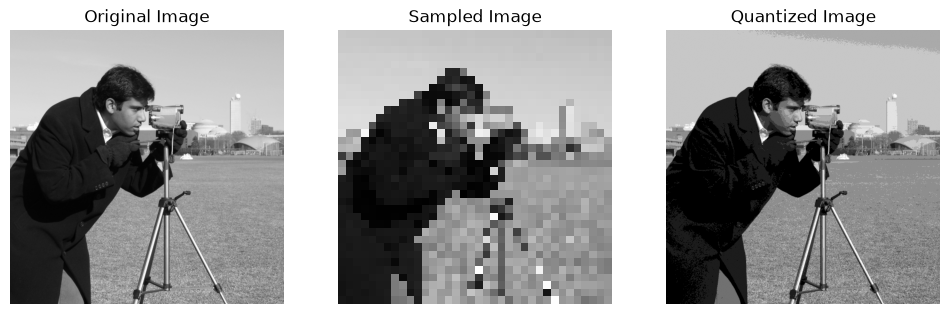

In [27]:
image_path = 'images/cameraman.tif'

sampling_factor = 14
quantization_levels = 9

original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    print("Error: image not found")
else:
    sampled_image = sample_image(original_image, sampling_factor)
    quantized_image = quantize_image(original_image, quantization_levels)

    plot_images(original_image, sampled_image, quantized_image)

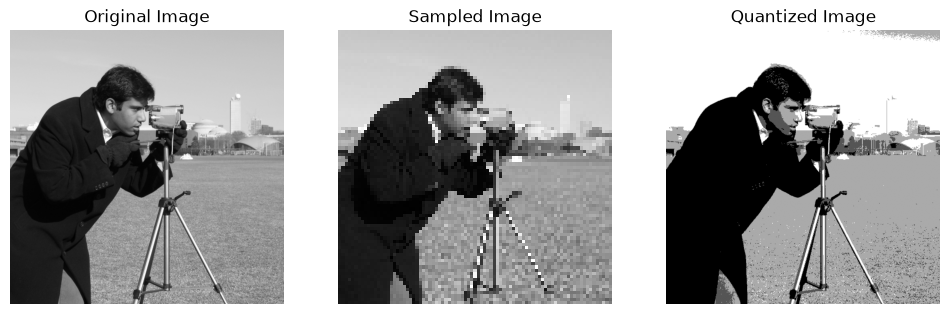

In [28]:
sampling_factor = 6
quantization_levels = 4

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

In [29]:
import skimage as ski

coins = ski.data.coins()
cv2.imwrite('images/coins.png', coins)

True

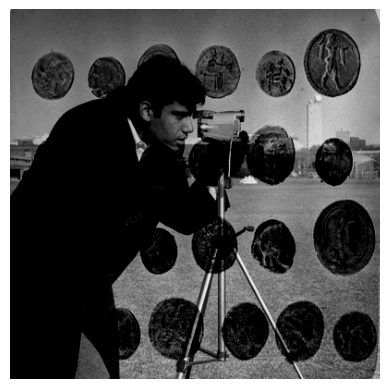

In [30]:
img1 = Image.open('images/cameraman.tif').convert('L')
img2 = Image.open('images/coins.png').convert('L')

resize = (400, 400)

img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1, dtype=np.int16)
im2arr = np.asarray(img2, dtype=np.int16)

subtraction = im1arr - im2arr
subtraction = np.clip(subtraction, 0, 255).astype(np.uint8)

plt.imshow(subtraction, cmap='gray')
plt.axis('off')
plt.show()

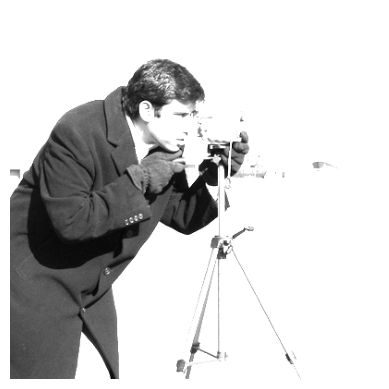

In [31]:
added_constant = im1arr + 175

added_constant = np.clip(added_constant, 0, 255).astype(np.uint8)

plt.imshow(added_constant, cmap='gray')
plt.axis('off')
plt.show()

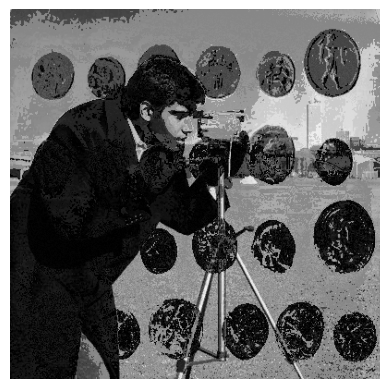

In [32]:
im1_uint8 = np.asarray(img1, dtype=np.uint8)
im2_uint8 = np.asarray(img2, dtype=np.uint8)

set_difference = im1_uint8 & (~im2_uint8)

plt.imshow(set_difference, cmap='gray')
plt.axis('off')
plt.show()

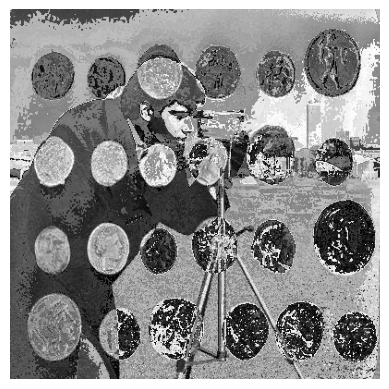

In [33]:
symmetric_difference = im1_uint8 ^ im2_uint8

plt.imshow(symmetric_difference, cmap='gray')
plt.axis('off')
plt.show()


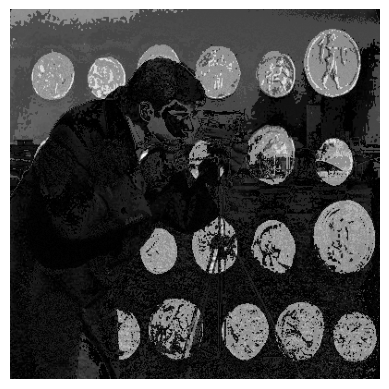

In [34]:
intersection = im1_uint8 & im2_uint8

plt.imshow(intersection, cmap='gray')
plt.axis('off')
plt.show()